#  MP307 Practical 4 Continuous Population Models

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

### Q1.(*) Verhulst Logistic Model.
Consider the logistic population model 
$$
\frac{dP}{dt}=rP\left(1-\frac{P}{K}\right)
$$
for $r,K>0$ as a model of the US population from 1790 to 1990. The data for
this are as given in the worksheet Q2. of `lab3_discrete_population_models.ipynb` as follows:

In [2]:
Year = [1790, 1820, 1830, 1840, 1850, 1860, 1870, 1880, 1890, 1900, 1910, 1920, 1930, 
        1940, 1950, 1960, 1970, 1980, 1990]
Pop= [3.79, 9.6, 12.9, 17.1, 23.2, 31.4, 38.6, 50.2, 62.9, 76.0, 92.0, 106.5, 123.2, 
      132.0, 151.3, 179.3, 203.3, 226.54, 248.7]

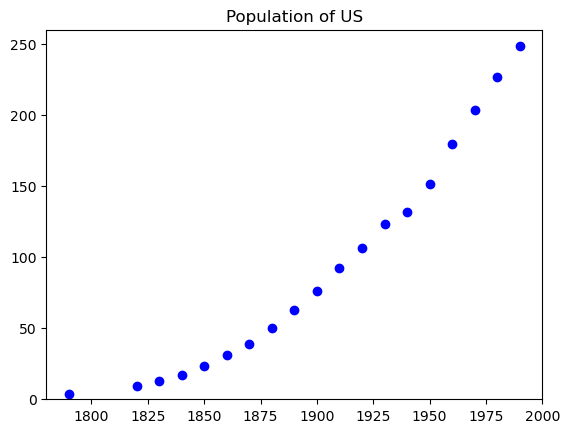

In [3]:
# plot of data
plt.figure(1)
plt.plot(Year,Pop,'bo')
plt.axis([1780,2000,0,260])
plt.title('Population of US')
plt.show()

The Logistic differential equation has solution
$$
P(t)=\frac{K}{1+\left(\frac{K}{P_{0}}-1\right)e^{-rt}}
%\left(1/K+(1/P_{0}-1/K) e^{-rt} \right)^{-1}
$$

In [4]:
#Logistic Model

# Python function for Logistic solution where t=0 is 1790
def P(t):
    P_0=3.79
    r=0.3 #  in inverse decades
    K=300.0
    ans=# TASK: fill this in yourself
    return ans

In [5]:
P(0)

3.79

In [6]:
# plot Verhulst pop PV from 1790 to 1990 with 10 year intervals
PV=[0]*21 # list for Verhulst P initialized with 20 zeros
YV=[0]*21 # list for years initialized with 20 zeros

# choose 10 year intervals
for n in range(1,21):
    YV[n]=1790+10*n
    PV[n]=P(n)

In [ ]:
plt.figure(2)
plt.plot(Year,Pop,'bo')
plt.plot(YV,PV,'r-')
plt.axis([1780,2000,0,260])
plt.title('Population of US')
plt.show()

The answer you get should look something like this:

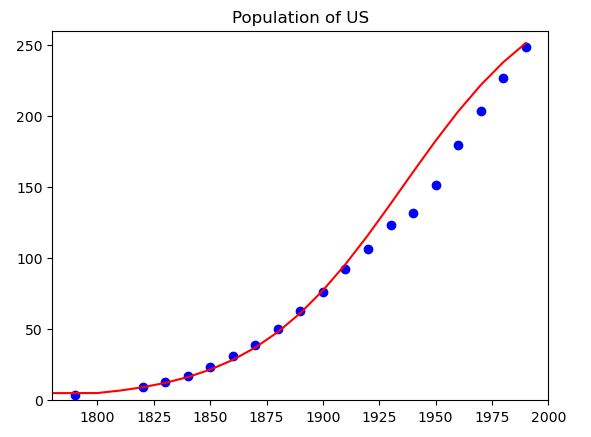

### Q.2(*) Competitive Species Model 
Consider two species with population sizes $P_{1},P_{2}$ with growth rates $r_{1},r_{2}$ and limiting population sizes
of $K_{1},K_{2}$ where 
\begin{eqnarray*}
\frac{dP_{1}}{dt} &=&r_{1}P_{1}\left(1-\frac{P_{1}+P_{2} }{K_{1}}\right),
\\
\frac{dP_{2}}{dt} &=&r_{2}P_{2}\left(1-\frac{P_{1}+P_{2}}{K_{2}}\right).
\end{eqnarray*}

Analyse the behaviour of $P_{1},P_{2}$ in the following cases, by plotting $
P_{1},P_{2}\,$vs $t$ and $P_{1}$ vs $P_{2}$:

(a). $r_{1}=1/10$, $r_{2}=1/10,$ $K_{1}=100$, $K_{2}=50$ with $P_{1}(0)=10$
and $P_{2}(0)=15.$

(b). $r_{1}=1/10$, $r_{2}=1/10,$ $K_{1}=100$, $K_{2}=50$ with $P_{1}(0)=130 
$ and $P_{2}(0)=200.$

(c). $r_{1}=1/10$, $r_{2}=1/100,$ $K_{1}=40$, $K_{2}=50$ with $P_{1}(0)=130 
$ and $P_{2}(0)=20.$

(d). $r_{1}=1/10$, $r_{2}=1/100,$ $K_{1}=50$, $K_{2}=60$ with $P_{1}(0)=15$
and $P_{2}(0)=10.$

In [8]:
# parameter values
r_1, r_2 = 1/10, 1/10

K_1, K_2 = 100, 50 

P1_0, P2_0 = 10, 15 # initial populations

Define a function `dP_dt(P, t)` of a Python list `P=[P1,P2]` describing dP1/dt and dP2/dt. 

Note: recall that indexing in Python goes 0,1,... so that Pop1 is stored in`P[0]` and Pop2 is stored in `P[1]`

In [9]:
def dP_dt(P, t): # P=[P1,P2] list
    return [r_1*P[0]*(1 - (P[0]+P[1])/K_1), # TASK: fill this in yourself \
           ] 

Use `odeint` Python function to integrate the pair of odes subject to the initial conditions for time from `tmin` to `tmax`. 

In [10]:
tmin=0
tmax=100.

ts = np.linspace(tmin, tmax, 100) # 100 equally spaced t values from tmin to tmax 
P0 = [P1_0, P2_0] #initial conditions
Ps = odeint(dP_dt, P0, ts)
P1 = Ps[:,0] # values of P1 on ts values
P2 = Ps[:,1] # values of P2 on ts values

Plot $P_{1}$ and $P_{2}$ vs $t$ and asymptotic lines.


In [ ]:
plt.figure(3)
plt.plot(ts, P1, "-", label="Pop 1")
plt.plot(ts, P2, "-", label="Pop 2")
plt.xlabel("Time")
plt.ylabel("Population")
plt.legend();

You should get something that looks like:

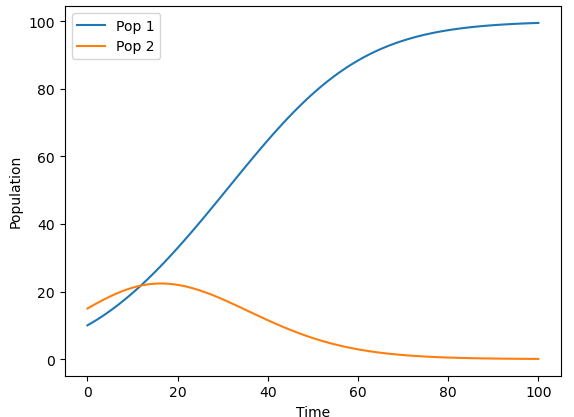

Notice that as $t\rightarrow \infty$ then $(P_{1},P_{2})\rightarrow (K_{1},0)$ for $K_{1}>K_{2}$ and  $(P_{1},P_{2})\rightarrow (0,K_{2})$ for $K_{1}<K_{2}$. 

We can add the asymptotic lines to the above graph as follows

In [ ]:
P1_infty, P2_infty = # TASK: fill this in yourself
if K_2>K_1:
    P1_infty, P2_infty = 0,K_2
plt.plot([tmin,tmax],[P1_infty,P1_infty],"b--")
plt.plot([tmin,tmax],[P2_infty,P2_infty],"r--")

plt.plot(ts, P1, "-", label="Pop 1")
plt.plot(ts, P2, "-", label="Pop 2")
plt.xlabel("Time")
plt.ylabel("Population")
plt.legend();

It should look like this:

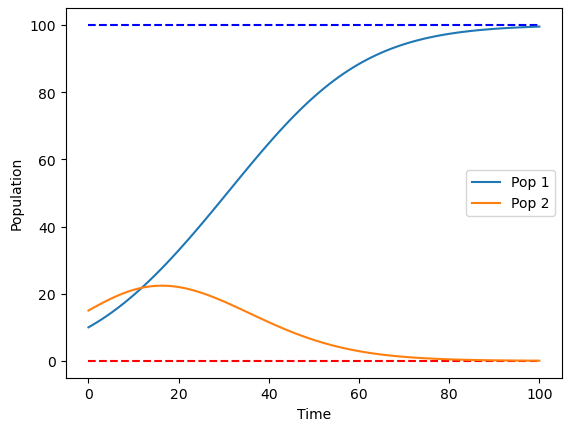

Plot $P_{1}$ vs $P_{2}$ with initial point marked with an x. We also plot the lines $P_{1}+P_{2}=K_{1}$ and $P_{1}+P_{2} =K_{2}$. 



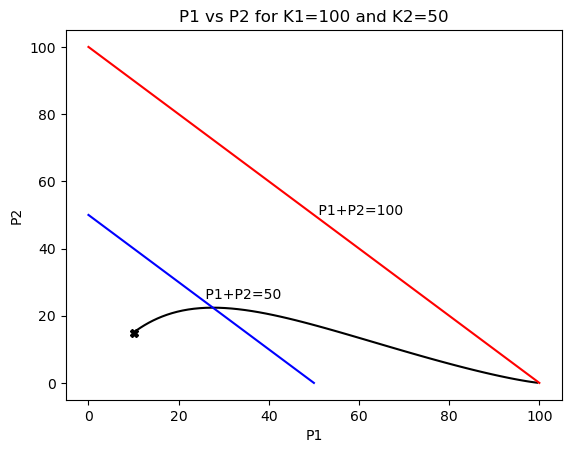

In [13]:
plt.figure(4)

plt.plot(P1_0, P2_0,'kX') # mark initial point with x

plt.plot(P1, P2, 'k-')
plt.plot([0,K_1],[K_1,0],'r-')
plt.plot([0,K_2],[K_2,0],'b-')
plt.text(K_1/2, K_1/2,' P1+P2='+str(K_1))
plt.text(K_2/2, K_2/2,' P1+P2='+str(K_2))
plt.xlabel("P1")
plt.ylabel("P2")
plt.title("P1 vs P2 for K1="+str(K_1)+" and K2="+str(K_2));


### Q.3(*) Lotka-Volterra Predator/Prey System
Consider a prey species with population size $x$ and a predator species with population size $y$
where 
\begin{eqnarray*}
\frac{dx}{dt} &=&x(a_{1}-b_{1}y), \\
\frac{dy}{dt} &=&y(-a_{2}+b_{2}x),
\end{eqnarray*}

with $a_{1}, a_{2}, b_{1}, b_{2}>0$. Analyse the behaviour of the system for $a_{1}=3, a_{2}=5/2$ and  $b_{1}=2,b_{2}=1$ by plotting $x,y$ vs $t$, and $x$ vs $y$ in the following cases:

(a). $x(0)=1$ and $y(0)=1$.

(b). $x(0)=0.1+5/2$ and $y(0)=0.1+3/2$. What behaviour do you observe?

(c).  $x(0)=1$ and $y(0)=5$.

Use similar coding to above

In [ ]:
a_1, a_2, b_1, b_2 = 3, 5/2, 2, 1

x0, y0 = 0.1+5/2, 0.1+3/2 # initial populations

timerange=6. 

def dP_dt(P, t): # P=[x,y] list
    return [P[0]*(a_1 - b_1*P[1]), # TASK: fill this in yourself \
           ] 

ts = np.linspace(0, timerange, 150)
P0 = [x0, y0] #initial conditions
Ps = odeint(dP_dt, P0, ts)
prey = Ps[:,0]
predators = Ps[:,1]

plt.figure(5)
plt.plot(ts, prey, "b-", label="Prey x")
plt.plot(ts, predators, "r-", label="Predator y")
plt.xlabel("Time")
plt.ylabel("Population")
plt.legend();

It should look something like this:

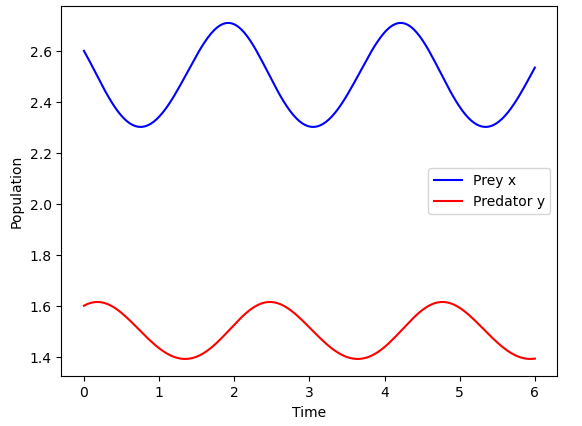

Equlibrium values $x_{eq}=a_{2}/b_{2}$ and $y_{eq}=a_{1}/b_{1}$. Notice that the maximum/minimum of $x$ occurs when $y=y_{eq}$ and similarly, the maximum/minimum of $y$ occurs when $x=x_{eq}$

In [15]:
xeq , yeq =a_2/b_2, a_1/b_1
print("(xeq,yeq)=",(xeq,yeq))

(xeq,yeq)= (2.5, 1.5)


Look at values of $x$ for $y=y_{eq}$ and of $y$ for $x=x_{eq}$ in the last plot

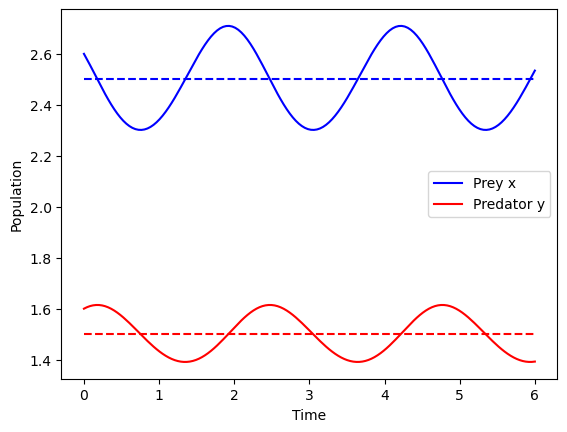

In [16]:
plt.plot([0,timerange],[xeq,xeq],"b--")
plt.plot([0,timerange],[yeq,yeq],"r--")

plt.plot(ts, prey, "b-", label="Prey x")
plt.plot(ts, predators, "r-", label="Predator y")
plt.xlabel("Time")
plt.ylabel("Population")
plt.legend();

Plot $x$ vs $y$ and show the equilibrium point. This plot shows that the system is periodic.

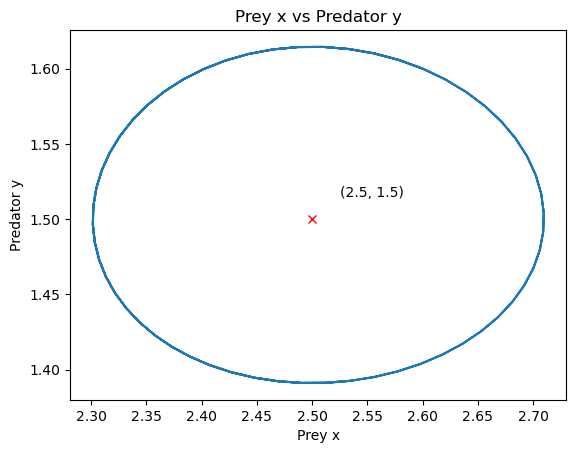

In [17]:
plt.figure(6)
plt.plot(prey, predators, "-")
plt.plot([xeq],[yeq],'rx')
plt.text(xeq*(1.01),yeq*(1.01),str((xeq,yeq)))
plt.xlabel("Prey x")
plt.ylabel("Predator y")
plt.title("Prey x vs Predator y");

Add lines $x=x_{eq}$ and $y=y_{eq}$ to this plot

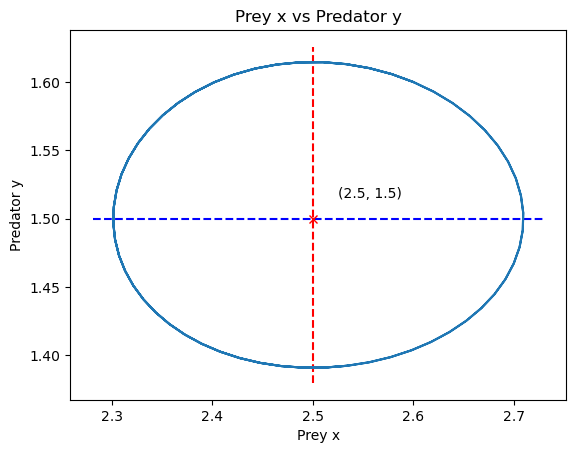

In [18]:
miny=min(predators)
maxy=max(predators)
dely=maxy-miny
plt.plot([xeq,xeq],[miny-dely*0.05,maxy+dely*0.05],"r--")

minx=min(prey)
maxx=max(prey)
delx=maxx-minx
plt.plot([minx-delx*0.05,maxx+delx*0.05],[yeq,yeq],"b--")

plt.plot(prey, predators, "-")
plt.plot([xeq],[yeq],'rx')
plt.text(xeq*(1.01),yeq*(1.01),str((xeq,yeq)))
plt.xlabel("Prey x")
plt.ylabel("Predator y")
plt.title("Prey x vs Predator y");